# E24 — Targeted Evaluation: Rule / FULL / RAG on the Checked-In Golden+Negative Battery

Offline; no model calls in this notebook (retrieval re-derivation below is deterministic BM25 +
rerank, also zero model calls — only the final classification call needs the model, and those
calls were already made in the saved run). Loads saved, already-executed results from
`results/run_E24_predictions.jsonl` (98 real hosted calls, $0.2184, 0 errors) and
`results/e24_analysis.json` (scored via `evaluation/evidence_matching.py`, the same functions
E17B/E20 use for the 2,091-case TEST scoring).

**What this is:** the first time the pre-registered golden/negative case battery has been run
against the *current* frozen architecture (previously only scored against the superseded legacy
pipeline — see `../../docs/test_coverage_summary.md`).

**What this is not:** a replacement for the 2,091-case official TEST benchmark
(`../E20_final_rag_test/`), which this experiment does not touch. 49 cases, deliberately curated
to include the hardest known case family — not statistically representative.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display, Markdown

A = json.loads(Path("results/e24_analysis.json").read_text())
manifest = {c["case_id"]: c for c in json.loads(Path("manifests/case_manifest.json").read_text())["cases"]}
preds = [json.loads(l) for l in open("results/run_E24_predictions.jsonl")]
by_case = {}
for p in preds: by_case.setdefault(p["case_id"], {})[p["system"]] = p
S = A["summary_by_system"]
print(json.dumps(S, indent=2))

{
  "rule": {
    "n": 49,
    "accuracy": 0.5102,
    "macro_f1": 0.4571,
    "joint_correctness": 0.449,
    "contradiction_recall": 0.1333,
    "notmentioned_recall": 0.9286,
    "total_cost_usd": 0,
    "mean_latency_ms": 0.0,
    "mean_input_tokens": 0.0
  },
  "full": {
    "n": 49,
    "accuracy": 0.7347,
    "macro_f1": 0.7196,
    "joint_correctness": 0.7347,
    "contradiction_recall": 0.4667,
    "notmentioned_recall": 0.7143,
    "total_cost_usd": 0.128221,
    "mean_latency_ms": 7983.7,
    "mean_input_tokens": 3177.6
  },
  "rag": {
    "n": 49,
    "accuracy": 0.7143,
    "macro_f1": 0.7079,
    "joint_correctness": 0.6735,
    "contradiction_recall": 0.5333,
    "notmentioned_recall": 0.7143,
    "total_cost_usd": 0.090187,
    "mean_latency_ms": 7302.4,
    "mean_input_tokens": 1117.5
  }
}


## 1. Aggregate results, all three systems

In [2]:
import pandas as pd
rows = []
for sysname in ("rule", "full", "rag"):
    s = S[sysname]
    rows.append({
        "System": sysname.upper(),
        "Accuracy": f"{s['accuracy']*100:.1f}%",
        "Macro-F1": f"{s['macro_f1']:.3f}",
        "Joint correctness": f"{s['joint_correctness']*100:.1f}%",
        "Contradiction recall": f"{s['contradiction_recall']*100:.1f}%" if s['contradiction_recall'] is not None else "n/a",
        "NotMentioned recall": f"{s['notmentioned_recall']*100:.1f}%" if s['notmentioned_recall'] is not None else "n/a",
        "Total cost": f"${s['total_cost_usd']:.4f}",
        "Mean latency": f"{s['mean_latency_ms']:.0f} ms",
    })
pd.DataFrame(rows).set_index("System")

,Accuracy,Macro-F1,Joint correctness,Contradiction recall,NotMentioned recall,Total cost,Mean latency
System,,,,,,,
RULE,51.0%,0.457,44.9%,13.3%,92.9%,$0.0000,0 ms
FULL,73.5%,0.720,73.5%,46.7%,71.4%,$0.1282,7984 ms
RAG,71.4%,0.708,67.3%,53.3%,71.4%,$0.0902,7302 ms


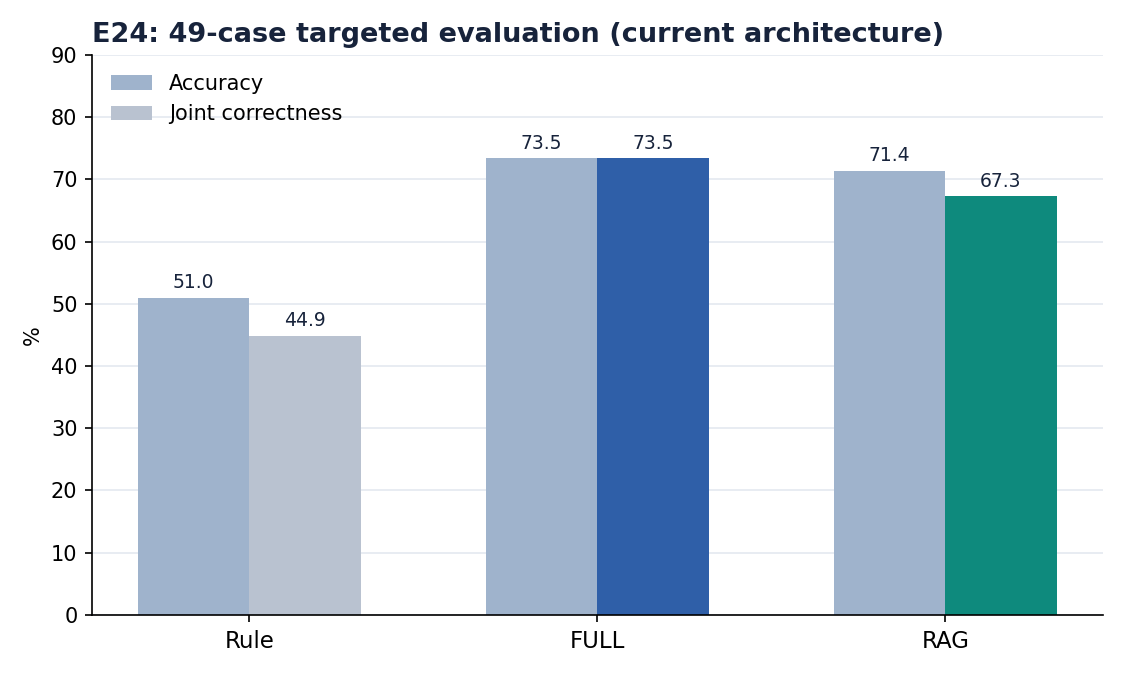

In [3]:
Image("figures/01_accuracy_joint.png")

## 2. Two populations, never merged into one number

Same architectures, same frozen configuration, two different case populations. The targeted set
is harder by design (it deliberately includes the documented hardest case family, ADR-011's
exception/carve-out cases) — lower numbers here do not revise the TEST benchmark.

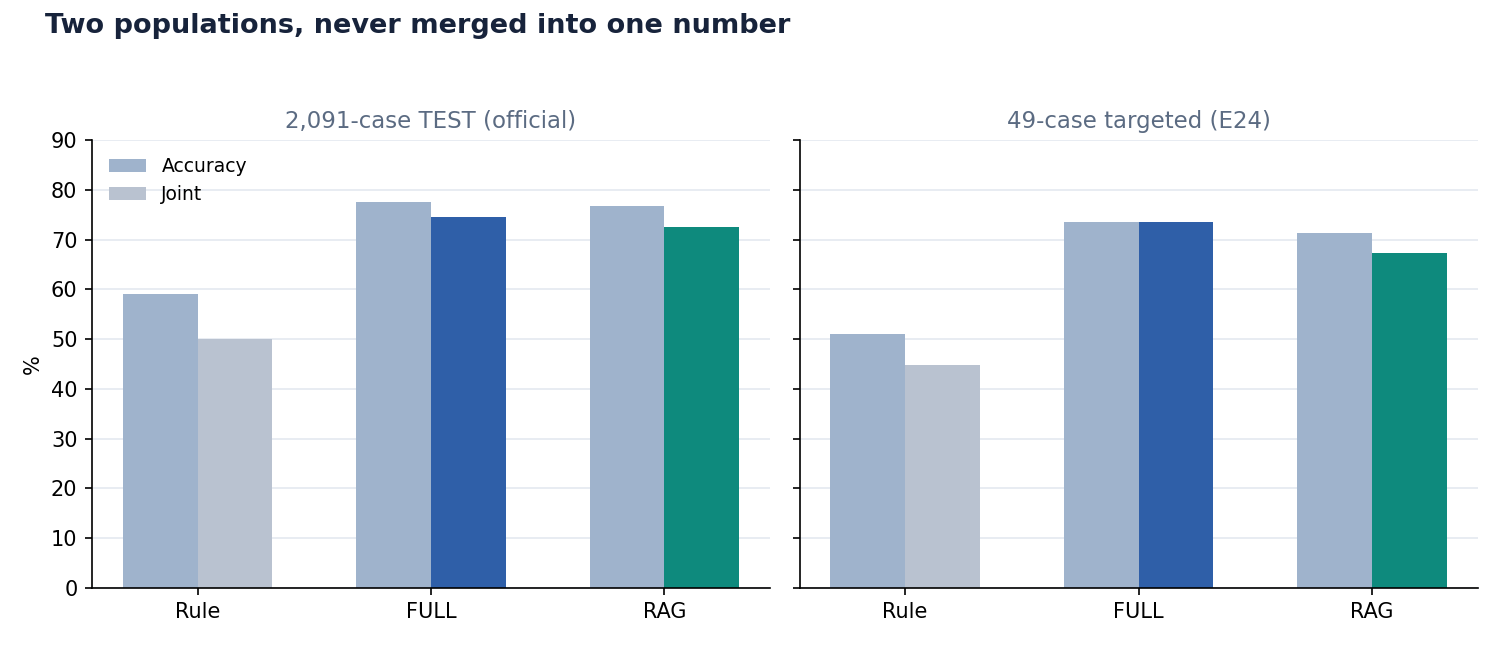

In [4]:
Image("figures/02_test_vs_targeted.png")

## 3. Category-level results (golden / negative / evidence_quality)

In [5]:
case_level = A["case_level"]
cat_rows = []
for group in ("golden", "negative", "evidence_quality"):
    ids = [cid for cid, c in manifest.items() if c["group"] == group]
    for sysname in ("rule", "full", "rag"):
        sub = [case_level[cid][sysname] for cid in ids]
        n = len(sub)
        if n == 0:
            continue
        acc = sum(s["label_correct"] for s in sub) / n
        joint = sum(s["joint_correct"] for s in sub) / n
        cat_rows.append({"Category": group, "System": sysname.upper(), "n": n,
                          "Accuracy": f"{acc*100:.1f}%", "Joint": f"{joint*100:.1f}%"})
pd.DataFrame(cat_rows).pivot(index="Category", columns="System", values=["Accuracy", "Joint"])

Accuracy                  Joint               
System               FULL     RAG   RULE    FULL     RAG   RULE
Category                                                       
evidence_quality   100.0%  100.0%   0.0%  100.0%  100.0%   0.0%
golden              80.0%   76.7%  60.0%   80.0%   73.3%  56.7%
negative            53.3%   53.3%  46.7%   53.3%   46.7%  33.3%

## 4. Failure analysis

Same categories as `summary.md`'s prose — reproduced here from the saved analysis, not
re-derived.

In [6]:
fa = A["failure_analysis"]

def describe(cid):
    c = manifest[cid]
    return f"{cid} ({c['group']}, gold={c['gold_label']}): {c['description'][:90]}"

print("All three systems wrong:")
for cid in fa["all_three_wrong"]:
    print(" -", describe(cid))

print("\nFULL right, RAG wrong:")
for cid in fa["full_right_rag_wrong"]:
    print(" -", describe(cid))

print("\nRAG right, FULL wrong:")
for cid in fa["rag_right_full_wrong"]:
    print(" -", describe(cid))

print("\nCorrect label, incorrect/insufficient evidence (RAG):")
for cid in fa["correct_label_incorrect_evidence"]["rag"]:
    print(" -", describe(cid))

All three systems wrong:
 - 001 (golden, gold=Entailment): Easy entailment - single clause, short NDA, obvious match
 - 011 (golden, gold=Contradiction): Easy contradiction - explicit carve-out / exclusion
 - 019 (golden, gold=Contradiction): Contradiction buried in a schedule/appendix reference [proxy: no keyword/structural match 
 - 034 (negative, gold=Contradiction): Misleading wording - "except as required by law" carve-out limits an apparently firm requi
 - 036 (negative, gold=NotMentioned): Wrong section evidence - topic language appears in the document's opening (recital-like) b
 - 039 (negative, gold=Contradiction): Conflicting clauses - amendment/override language should win over an earlier, superseded c
 - 040 (negative, gold=Contradiction): Conflicting clauses - a specific exception should override an apparently general requireme

FULL right, RAG wrong:
 - 005 (golden, gold=Entailment): Medium entailment - legal jargon ("strictest confidence" / "receiving party")
 - 017 (gol

## 5. Deep diagnostic: cases 007 and 043 (RAG's evidence-only failures)

RAG predicts the correct label on both, but cited evidence falls below the joint-correctness
threshold (`TAU_EVIDENCE = 0.5` — at least half of the gold-annotated spans must be covered).
Retrieval is re-derived offline below (deterministic BM25 + rerank, zero model calls) to check
whether the gold evidence was structurally available to RAG at all.

In [7]:
import sys
sys.path.insert(0, "../..")
from pipeline.frozen_rag import FrozenRagRetriever
from evaluation import evidence_matching as EM

for cid in ["007", "043"]:
    c = manifest[cid]
    print("="*90, "CASE", cid, "-", c["description"])
    print("hypothesis:", c["hypothesis_text"])
    print("gold_label:", c["gold_label"], " gold_span_indices:", c["gold_span_indices"])

    retriever = FrozenRagRetriever(c["nda_text"])
    retrieved = retriever.retrieve(c["hypothesis_text"])
    retrieved_text = " ".join(ch.text for ch in retrieved)
    covered = [EM.is_source_valid(g, retrieved_text) for g in c["gold_evidence"]]
    print(f"gold spans retrievable in RAG's actual top-{len(retrieved)}: {sum(covered)}/{len(covered)} -> {covered}")

    for s in ("full", "rag"):
        pred = by_case[cid][s]
        ev = pred.get("evidence") or []
        pred_idx = EM.evidence_to_span_indices(ev, [c["nda_text"]], [[0, len(c["nda_text"])]], c["doc_spans"])
        overlap = set(pred_idx) & set(c["gold_span_indices"])
        frac = len(overlap) / len(c["gold_span_indices"])
        print(f"  [{s}] label={pred['predicted_label']}  cited_spans={pred_idx}  "
              f"gold_overlap={sorted(overlap)}  coverage={frac*100:.0f}%  "
              f"{'PASSES' if frac >= 0.5 else 'FAILS'} tau=0.5")
    print()

========================================================================================== CASE 007 - Hard entailment - evidence scattered across 3+ spans
hypothesis: Receiving Party shall not use any Confidential Information for any purpose other than the purposes stated in Agreement.
gold_label: Entailment  gold_span_indices: [12, 13, 33, 36]


gold spans retrievable in RAG's actual top-5: 2/4 -> [False, False, True, True]
  [full] label=Entailment  cited_spans=[12, 13, 36]  gold_overlap=[12, 13, 36]  coverage=75%  PASSES tau=0.5
  [rag] label=Entailment  cited_spans=[36, 51]  gold_overlap=[36]  coverage=25%  FAILS tau=0.5

========================================================================================== CASE 043 - Keyword absence - an abbreviation/defined short-form is used in place of the full term
hypothesis: Confidential Information may include verbally conveyed information.
gold_label: Entailment  gold_span_indices: [28, 29, 30]


gold spans retrievable in RAG's actual top-5: 2/3 -> [False, True, True]
  [full] label=Entailment  cited_spans=[29, 30, 61]  gold_overlap=[29, 30]  coverage=67%  PASSES tau=0.5
  [rag] label=Entailment  cited_spans=[29, 61]  gold_overlap=[29]  coverage=33%  FAILS tau=0.5



**Reading the output above**: in both cases, some gold spans are never in RAG's retrieved
context at all (a real retrieval-coverage gap), and FULL's full-document access reaches a higher
coverage fraction simply by having every span available to cite. In case 007 specifically, RAG's
own cited spans also don't include every gold span that *was* retrieved — so this is a combined
retrieval-coverage-and-selection failure, not purely one or the other.

## 6. The persistent exception/carve-out weakness (ADR-011), and case 038's context-selection finding

Of the 4 documented exception-family cases in this battery (034, 038, 039, 040), only 038 is
correctly handled under the current architecture, and only by RAG — FULL still gets it wrong. 034,
039, 040 fail under *every* system, matching the legacy pipeline's own 100%-failure finding on
this case family.

In [8]:
for cid in ["034", "038", "039", "040"]:
    c = manifest[cid]; cl = A["case_level"][cid]
    print(f"{cid}: gold={c['gold_label']:13s}  rule={cl['rule']['predicted_label']:13s}  "
          f"full={cl['full']['predicted_label']:13s}  rag={cl['rag']['predicted_label']:13s}")
    print(f"      {c['description'][:110]}")

034: gold=Contradiction  rule=NotMentioned   full=Entailment     rag=Entailment   
      Misleading wording - "except as required by law" carve-out limits an apparently firm requirement
038: gold=Contradiction  rule=NotMentioned   full=Entailment     rag=Contradiction
      Conflicting clauses - evidence spans multiple locations, approximating one clause granting and another limitin
039: gold=Contradiction  rule=NotMentioned   full=Entailment     rag=Entailment   
      Conflicting clauses - amendment/override language should win over an earlier, superseded clause [proxy: no key
040: gold=Contradiction  rule=NotMentioned   full=Entailment     rag=Entailment   
      Conflicting clauses - a specific exception should override an apparently general requirement


**Case 038, traced at the clause level**: FULL cited a real clause — *"may disclose VA sensitive
information... in only two situations: (1) court order, (2) VA's prior written authorization"* —
and predicted Entailment, apparently over-weighting that permissive-sounding clause against the
document's overall restrictive framing. RAG's narrower top-5 retrieval did not surface that
clause at all, foregrounded the restrictive clauses instead, and predicted Contradiction —
correct. One traceable instance where full-document access was a liability, not an asset.

## 7. Case 001 — debatable ground-truth annotation

Hypothesis: *"Confidential Information shall only include technical information."* Gold evidence
is an export-control clause (technical-data transmission restrictions) that does not
substantively address the hypothesis. Confirmed the gold clause **is** in every system's
available context (re-derived retrieval above would show the same for RAG specifically) — this is
not a retrieval problem for any architecture. Matches a pre-existing, independent finding in
`docs/experiment_registry.md`'s T012 entry: *"the model's disagreement with gold there is
arguably more defensible than the label itself."* Counted as an evaluation-validity caveat, not a
reasoning failure, in `summary.md`.

## Limitations

- 49 cases, not statistically representative; deliberately includes the hardest known family.
- Single run per case, temperature 0, no repeated-sampling variance estimate.
- `injection_cases.json`/`llm_behaviour_cases.json` not re-executed (synthetic docs, no stored
  source text) — security robustness remains characterized by E16/E21/E22/E23, unchanged.
- Case difficulty tiers ("easy"/"medium"/"hard") were assigned under the legacy pipeline's design
  process and are not re-validated as accurate for the current architecture (see case 001).